<a href="https://colab.research.google.com/github/shashikantbaragi/image-processing-lab/blob/main/noiseimage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

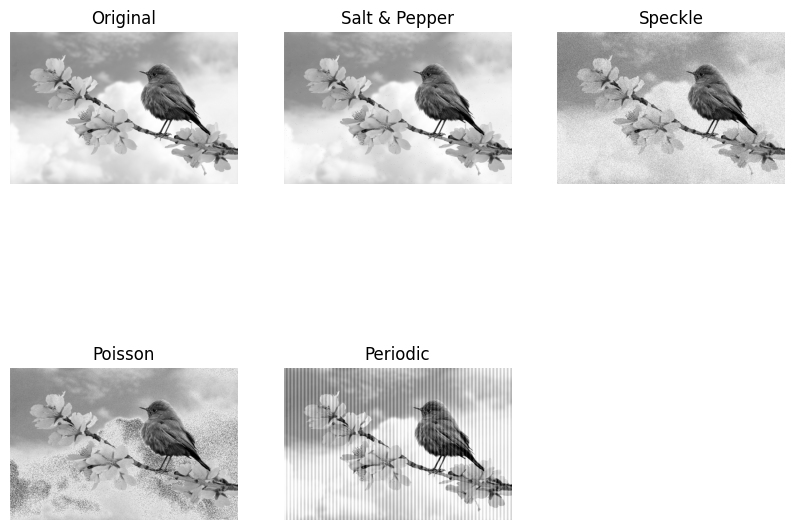

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("/content/bird-8788491_1280.jpg", 0)

# 1. Salt and Pepper Noise
sp = img.copy()

# Add white pixels (Salt)
for i in range(500):
    x = np.random.randint(0, img.shape[0])
    y = np.random.randint(0, img.shape[1])
    sp[x, y] = 255

# Add black pixels (Pepper)
for i in range(500):
    x = np.random.randint(0, img.shape[0])
    y = np.random.randint(0, img.shape[1])
    sp[x, y] = 0


# 2. Speckle Noise
speckle = img + img * np.random.randn(*img.shape) * 0.2
speckle = np.clip(speckle, 0, 255).astype(np.uint8)


# 3. Poisson Noise
poisson = np.random.poisson(img).astype(np.uint8)


# 4. Periodic Noise
rows, cols = img.shape
x = np.arange(cols)
periodic = 30 * np.sin(2 * np.pi * x / 20)
periodic = np.tile(periodic, (rows, 1))

periodic_noise = img.astype(float) + periodic
periodic_noise = np.clip(periodic_noise, 0, 255).astype(np.uint8)


# Display
plt.figure(figsize=(10, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(sp, cmap="gray")
plt.title("Salt & Pepper")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(speckle, cmap="gray")
plt.title("Speckle")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(poisson, cmap="gray")
plt.title("Poisson")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(periodic_noise, cmap="gray")
plt.title("Periodic")
plt.axis("off")

plt.show()